### Import librairies

In [35]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.special import ndtr, ndtri

# Find the project root so this notebook also works when launched from a subfolder.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "python_module" / "pricing_model.py").is_file():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find python_module/pricing_model.py from the notebook directory")

sns.set_theme()
# Show large numbers as 1_000_000; small ones (deltas, weights, prices) keep 4 significant digits
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")

from python_module.pricing_model import BSMModel, MultiAssetBSMModel, SABRModel

### Inputs

In [36]:
# Pricing parameters
S0 = 100.0                                  # spot
K = 100.0                                   # strike
T = 20 / 252                                # maturity (years)
r = 0.00                                    # risk-free rate
sigma = 0.20                                # volatility

# Monte Carlo parameters
n_paths = 10_000                            # MC paths (~0.1 MB per path at 20 steps x 100 options)
n_steps = max(1, round(T * 252))            # MC steps
seed = 42                                   # random seed
simulation_sigma = 0.20                     # volatility used for simulation

# Portfolio parameters
n_options = 100                             # number of options in the portfolio    
lower_bound_delta = -0.01                   # lower delta strike to be included in the portfolio
upper_bound_delta = 0.01                    # upper delta strike to be included in the portfolio
t0_gamma_cash = 50_000_000

# Strike reduction parameters
n_selected_options = 10                     # max number of options kept by the lasso
train_fraction = 0.7                        # share of paths used to fit, the rest is out-of-sample

### Option portfolio creation

In [37]:
# Forward and strike bounds: closed-form inversion of the Black-76 delta
# call delta = disc * N(d1), put delta = disc * (N(d1) - 1), K = F * exp(-d1 * sigma * sqrt(T) + sigma^2 * T / 2)
F0 = BSMModel.compute_forward(S0, T, r, 0.0, 0.0)
discount = np.exp(-r * T)
d1_lower = ndtri(1 + lower_bound_delta / discount)
d1_upper = ndtri(upper_bound_delta / discount)
K_lower = F0 * np.exp(-d1_lower * sigma * np.sqrt(T) + 0.5 * sigma ** 2 * T)
K_upper = F0 * np.exp(-d1_upper * sigma * np.sqrt(T) + 0.5 * sigma ** 2 * T)

# Equally spaced strike grid; S_star is the node closest to the forward (put / call boundary)
strikes = np.linspace(K_lower, K_upper, n_options)
dK = strikes[1] - strikes[0]
S_star = strikes[np.argmin(np.abs(strikes - F0))]

# Variance swap replication (Demeterfi-Derman-Kamal-Zou): replicate the log contract
# f(S) = 2/T * [(S - S_star) / S_star - ln(S / S_star)] by its piecewise-linear interpolant on the strike nodes.
# The weight of each option is the slope change (kink) of the interpolant at its strike.
# One ghost node on each side lets the boundary strikes carry weight instead of being wasted.
def log_contract(S):
    return 2 / T * ((S - S_star) / S_star - np.log(S / S_star))

nodes = np.concatenate([[K_lower - dK], strikes, [K_upper + dK]])
slopes = np.diff(log_contract(nodes)) / np.diff(nodes)
weights = np.diff(slopes)                                   # ~ 2 * dK / (T * K^2)

portfolio = pd.DataFrame({
    "strike": strikes,
    "option_type": np.where(strikes < S_star, "put", "call"),
    "weight": weights,
})
portfolio["delta"] = [
    BSMModel.compute_option_with_forward(F0, k, T, r, sigma, o, compute_greeks=True)["delta"]
    for k, o in zip(portfolio["strike"], portfolio["option_type"])
]
portfolio["price"] = [
    BSMModel.compute_option_with_forward(F0, k, T, r, sigma, o)
    for k, o in zip(portfolio["strike"], portfolio["option_type"])
]

# Scale the unit replication weights so the portfolio gamma cash (Gamma * S^2 / 100) at t0 and S0 equals t0_gamma_cash
unit_gamma = BSMModel.compute_option_with_forward(F0, strikes, T, r, sigma, "call", compute_greeks=True)["gamma"]
unit_gamma_cash = (weights * unit_gamma).sum() * np.exp(2 * r * T) * S0 ** 2 / 100
scale = t0_gamma_cash / unit_gamma_cash
portfolio["quantity"] = portfolio["weight"] * scale

# Sanity check: fair variance implied by the replicating portfolio vs sigma^2.
# Holding only a call at S_star (instead of put + call) shifts the payoff by the linear term -slope_left * (S - S_star).
slope_left_star = slopes[np.searchsorted(nodes, S_star) - 1]
expected_log_contract = (portfolio["weight"] * portfolio["price"]).sum() / discount + slope_left_star * (F0 - S_star)
fair_variance = 2 / T * (r * T - (F0 / S_star - 1) - np.log(S_star / S0)) + expected_log_contract
print(f"Strike range: [{K_lower:.2f}, {K_upper:.2f}], dK = {dK:.4f}, S* = {S_star:.2f}")
print(f"Replicated fair vol: {np.sqrt(fair_variance):.4%} vs sigma: {sigma:.4%}")
print(f"Quantity scale: {scale:,.0f} (t0 gamma cash = {t0_gamma_cash:,.0f})")
display(portfolio)

Strike range: [87.85, 114.19], dK = 0.2660, S* = 100.09
Replicated fair vol: 19.9641% vs sigma: 20.0000%
Quantity scale: 202,239,106 (t0 gamma cash = 50,000,000)


,strike,option_type,weight,delta,price,quantity
0,87.85,put,0.0008684,-0.01,0.01943,175_625
1,88.12,put,0.0008632,-0.01152,0.02275,174_566
2,88.39,put,0.000858,-0.01324,0.02655,173_517
3,88.65,put,0.0008528,-0.01516,0.03089,172_477
4,88.92,put,0.0008477,-0.01731,0.03585,171_447
...,...,...,...,...,...,...
95,113.1,call,0.0005238,0.01538,0.03026,105_929
96,113.4,call,0.0005213,0.01384,0.0269,105_433
97,113.7,call,0.0005189,0.01243,0.02388,104_940
98,113.9,call,0.0005165,0.01116,0.02118,104_450


### Gamma Grid

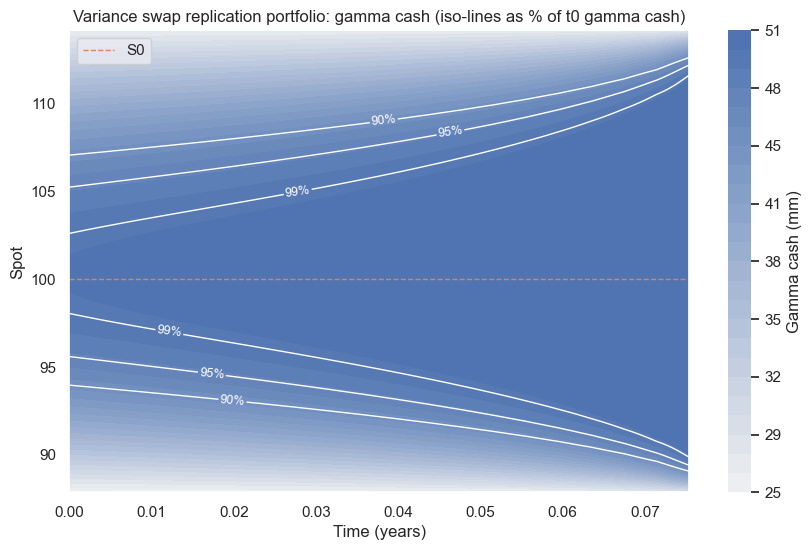

In [38]:
# Portfolio gamma cash (Gamma * S^2 / 100, P&L per 1% move squared) on a spot x time grid.
# The spot grid spans the strike range; the last time step is excluded since gamma is singular at expiry.
spot_grid = np.linspace(K_lower, K_upper, 200)
time_grid = np.linspace(0.0, T, n_steps + 1)[:-1]
quantities = portfolio["quantity"].to_numpy()

gamma_cash = np.empty((spot_grid.size, time_grid.size))
for j, t in enumerate(time_grid):
    tau = T - t
    F_grid = spot_grid[:, None] * np.exp(r * tau)
    greeks = BSMModel.compute_option_with_forward(F_grid, strikes[None, :], tau, r, sigma, "call", compute_greeks=True)
    gamma_spot = greeks["gamma"] * np.exp(2 * r * tau)     # forward gamma -> spot gamma (same for calls and puts)
    gamma_cash[:, j] = (gamma_spot @ quantities) * spot_grid ** 2 / 100

# Filled contours in millions, with labelled iso-lines at fractions of the t0 target to show where the replication holds
gamma_cash_mm = gamma_cash / 1e6
fill_levels = np.linspace(gamma_cash_mm.min(), gamma_cash_mm.max(), 25)
line_levels = t0_gamma_cash / 1e6 * np.array([0.90, 0.95, 0.99])

# Sequential colormap built from the seaborn theme palette (same blue as the terminal payoff plot)
theme_cmap = sns.light_palette(sns.color_palette()[0], as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 6))
filled = ax.contourf(time_grid, spot_grid, gamma_cash_mm, levels=fill_levels, cmap=theme_cmap)
lines = ax.contour(time_grid, spot_grid, gamma_cash_mm, levels=line_levels, colors="white", linewidths=1)
ax.clabel(lines, fmt=lambda v: f"{v / (t0_gamma_cash / 1e6):.0%}", fontsize=9)
cbar = fig.colorbar(filled, ax=ax, format="%.0f")
cbar.set_label("Gamma cash (mm)")
cbar.outline.set_visible(False)
ax.axhline(S0, color=sns.color_palette()[1], linewidth=1, linestyle="--", label="S0")
ax.grid(False)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Spot")
ax.set_title("Variance swap replication portfolio: gamma cash (iso-lines as % of t0 gamma cash)")
ax.legend(loc="upper left", frameon=True)
plt.show()

### Terminal Payoff

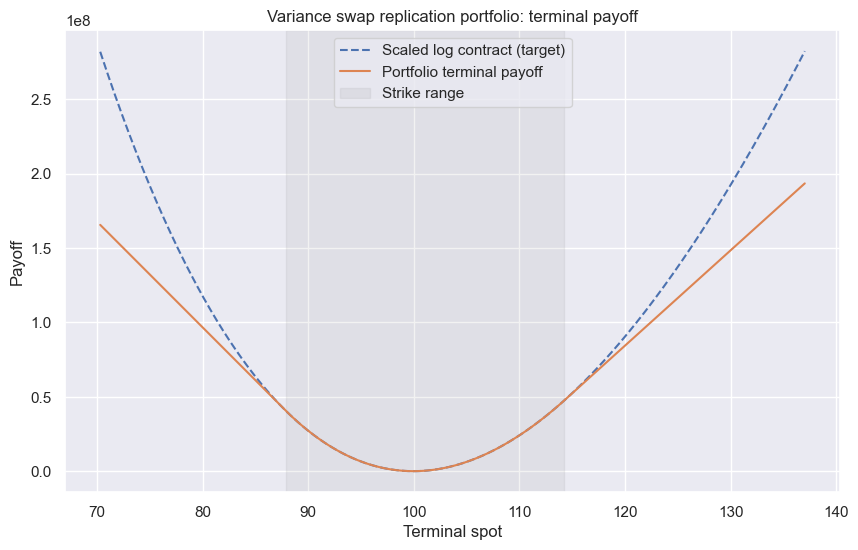

In [39]:
# Terminal payoff of the scaled portfolio vs the scaled log contract it replicates.
# The target includes the linear term from holding only a call at S_star: scale * [f(S) - slope_left * (S - S_star)].
terminal_spot = np.linspace(0.8 * K_lower, 1.2 * K_upper, 1_000)
is_call = (portfolio["option_type"] == "call").to_numpy()
intrinsic = np.where(
    is_call[None, :],
    np.maximum(terminal_spot[:, None] - strikes[None, :], 0.0),
    np.maximum(strikes[None, :] - terminal_spot[:, None], 0.0),
)
terminal_payoff = intrinsic @ quantities
target_payoff = scale * (log_contract(terminal_spot) - slope_left_star * (terminal_spot - S_star))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(terminal_spot, target_payoff, linestyle="--", label="Scaled log contract (target)")
ax.plot(terminal_spot, terminal_payoff, label="Portfolio terminal payoff")
ax.axvspan(K_lower, K_upper, alpha=0.1, color="gray", label="Strike range")
ax.set_xlabel("Terminal spot")
ax.set_ylabel("Payoff")
ax.set_title("Variance swap replication portfolio: terminal payoff")
ax.legend(loc="upper center")
plt.show()

### Montecarlo simulation

In [40]:
# Simulate GBM spot paths with simulation_sigma; options are priced and delta hedged daily with the pricing sigma
spot_paths = BSMModel.compute_montecarlo(S0, T, r, 0.0, 0.0, simulation_sigma, n_steps, n_paths, seed=True, seed_value=seed).to_numpy().T
dt = T / n_steps
step_index = pd.RangeIndex(1, n_steps + 1, name="step")                    # step i is the P&L over day i (from step i-1 to i)
spot_step_index = pd.RangeIndex(0, n_steps + 1, name="step")               # spot fixings, step 0 is S0

portfolio["name"] = portfolio["option_type"] + "_" + portfolio["strike"].round(2).astype(str)
option_names = portfolio["name"].tolist()
is_call = (portfolio["option_type"] == "call").to_numpy()

# Option values and spot deltas on every path, step and strike: shape (n_paths, n_steps + 1, n_options)
values = np.empty((n_paths, n_steps + 1, n_options))
deltas = np.zeros((n_paths, n_steps + 1, n_options))
for j in range(n_steps + 1):
    tau = T - j * dt
    S_j = spot_paths[:, j][:, None]
    if j == n_steps:
        values[:, j] = np.where(is_call, np.maximum(S_j - strikes, 0.0), np.maximum(strikes - S_j, 0.0))
        continue
    F_j = S_j * np.exp(r * tau)
    for option_type, mask in (("call", is_call), ("put", ~is_call)):
        res = BSMModel.compute_option_with_forward(F_j, strikes[mask], tau, r, sigma, option_type, compute_greeks=True)
        values[:, j, mask] = res["price"]
        deltas[:, j, mask] = res["delta"] * np.exp(r * tau)      # forward delta -> spot delta

# Daily position P&L (scaled by quantity). The hedge is short delta in spot, with the cash account financed at r.
dS = np.diff(spot_paths, axis=1)[:, :, None]
option_pnl = np.diff(values, axis=1) * quantities
delta_hedge_pnl = (-deltas[:, :-1] * dS + r * dt * (deltas[:, :-1] * spot_paths[:, :-1, None] - values[:, :-1])) * quantities
delta_hedged_option_pnl = option_pnl + delta_hedge_pnl
portfolio_pnl = delta_hedged_option_pnl.sum(axis=2)

# result_dict[path] -> {"option", "delta_hedge", "delta_hedged_option": DataFrame(step x option),
#                      "portfolio_delta_hedged": DataFrame(step x portfolio), "spot_timeseries": DataFrame(step x spot)}
result_dict = {
    path: {
        "option": pd.DataFrame(option_pnl[path], index=step_index, columns=option_names),
        "delta_hedge": pd.DataFrame(delta_hedge_pnl[path], index=step_index, columns=option_names),
        "delta_hedged_option": pd.DataFrame(delta_hedged_option_pnl[path], index=step_index, columns=option_names),
        "portfolio_delta_hedged": pd.DataFrame({"portfolio": portfolio_pnl[path]}, index=step_index),
        "spot_timeseries": pd.DataFrame({"spot": spot_paths[path]}, index=spot_step_index),
    }
    for path in range(n_paths)
}

# Sanity check: with simulation_sigma == sigma the delta hedged portfolio P&L should be centred on zero
total_portfolio_pnl = portfolio_pnl.sum(axis=1)
print(f"Portfolio premium: {(portfolio['quantity'] * portfolio['price']).sum():,.0f}")
print(f"Delta hedged portfolio total P&L: mean = {total_portfolio_pnl.mean():,.0f}, std = {total_portfolio_pnl.std():,.0f}")
# Per-path summary: annualised realised volatility (zero-mean, variance swap convention) and total hedged portfolio P&L
log_returns = np.diff(np.log(spot_paths), axis=1)
summary = pd.DataFrame(
    {
        "realized_volatility": np.sqrt((log_returns ** 2).sum(axis=1) / T),
        "portfolio_hedged_pnl": total_portfolio_pnl,
    },
    index=pd.RangeIndex(n_paths, name="path"),
)
display(summary.head())

Portfolio premium: 8,056,525
Delta hedged portfolio total P&L: mean = 2,074, std = 2,505,954


,realized_volatility,portfolio_hedged_pnl
path,,
0,0.1905,-724_782
1,0.1964,-293_234
2,0.1601,-2_887_691
3,0.2169,1_402_481
4,0.1348,-4_399_438


### Optimal strike reduction

Selected 10 of 100 options (alpha = 27_719_525_469)
R2 train = 0.9357, R2 test = 0.9336
Tracking error std (test) = 659_411 vs portfolio P&L std = 2_558_521


,strike,option_type,quantity,multiplier,reduced_quantity
put_95.04,95.04,put,150_085,17.53,2_630_819
put_96.9,96.9,put,144_373,0.2466,35_609
put_97.16,97.16,put,143_584,3.139,450_766
put_97.7,97.7,put,142_024,2.283,324_269
put_98.49,98.49,put,139_732,2.621,366_251
put_98.76,98.76,put,138_981,1.925,267_593
put_99.82,99.82,put,136_034,3.913,532_260
call_100.89,100.9,call,133_180,3.732,496_973
call_101.69,101.7,call,131_098,4.118,539_860
call_104.08,104.1,call,125_137,19.94,2_495_607


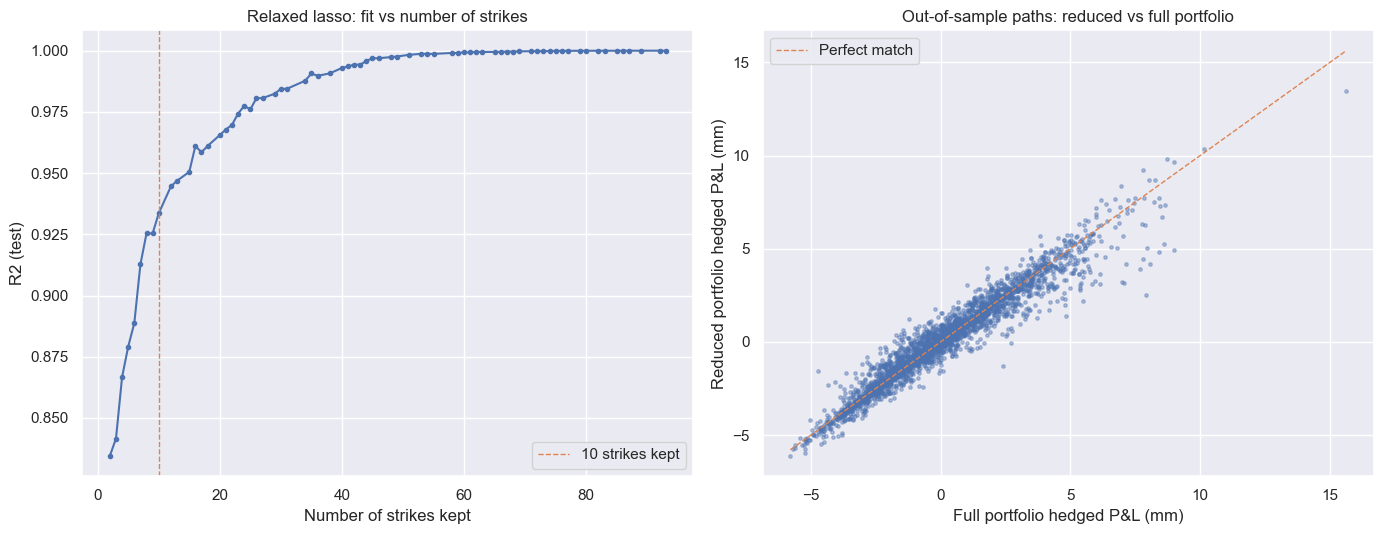

In [41]:
from scipy.optimize import lsq_linear, nnls
from sklearn.linear_model import lasso_path

# Features: total delta hedged P&L of each option position per path (same as result_dict[path]["delta_hedged_option"].sum()).
# Target: total delta hedged portfolio P&L per path. Using quantity-scaled positions makes each coefficient a multiplier
# of the original quantity (the full portfolio is all ones), so the L1 penalty treats every strike on the same footing.
X = pd.DataFrame(delta_hedged_option_pnl.sum(axis=1), index=summary.index, columns=option_names)
y = summary["portfolio_hedged_pnl"]

rng = np.random.default_rng(seed)
train_mask = rng.random(n_paths) < train_fraction
X_train, y_train, X_test, y_test = X[train_mask], y[train_mask], X[~train_mask], y[~train_mask]

def r2(target, fitted):
    return 1 - ((target - fitted) ** 2).sum() / ((target - target.mean()) ** 2).sum()

def nonnegative_least_squares(A, b):
    """min ||A x - b|| s.t. x >= 0. Columns are normalised first since neighbouring strikes are nearly collinear;
    falls back to lsq_linear when nnls does not converge."""
    col_norm = np.linalg.norm(A, axis=0)
    A_scaled, b_scale = A / col_norm, np.linalg.norm(b)
    try:
        x, _ = nnls(A_scaled, b / b_scale, maxiter=100 * A.shape[1])
    except RuntimeError:
        x = lsq_linear(A_scaled, b / b_scale, bounds=(0, np.inf)).x
    return x * b_scale / col_norm

def relaxed_lasso(X_train, y_train, X_test, y_test, max_strikes):
    """Long-only lasso path without intercept (the target is an exact sum of the features), then an unpenalised
    long-only refit on each support to remove the L1 shrinkage. The refit can zero out some strikes, so candidates are
    ranked on their effective number of strikes. Returns all candidates and the best in-sample fit within max_strikes
    (the test set is only used for reporting)."""
    alphas, coefs, _ = lasso_path(X_train.to_numpy(), y_train.to_numpy(), positive=True, n_alphas=200, max_iter=10_000)
    candidates = []
    for i in np.flatnonzero((coefs > 0).any(axis=0)):
        support = X_train.columns[coefs[:, i] > 0]
        coef = nonnegative_least_squares(X_train[support].to_numpy(), y_train.to_numpy())
        kept = support[coef > 0]
        candidates.append({
            "alpha": alphas[i],
            "n_strikes": len(kept),
            "strikes": kept,
            "coef": coef[coef > 0],
            "r2_train": r2(y_train, X_train[support].to_numpy() @ coef),
            "r2_test": r2(y_test, X_test[support].to_numpy() @ coef),
        })
    candidates = pd.DataFrame(candidates)
    best = candidates[candidates["n_strikes"] <= max_strikes].sort_values("r2_train").iloc[-1]
    return candidates, best

def reduced_positions(best):
    """Selected options with their multiplier of the original quantity and the resulting reduced quantity."""
    reduced = portfolio.set_index("name").loc[best["strikes"], ["strike", "option_type", "quantity"]]
    reduced["multiplier"] = best["coef"]
    reduced["reduced_quantity"] = reduced["quantity"] * reduced["multiplier"]
    return reduced

def pnl_r2_test(reduced):
    """Out-of-sample R2 of a reduced portfolio on the delta hedged P&L objective (common yardstick across methods)."""
    return r2(y_test, X_test[reduced.index].to_numpy() @ reduced["multiplier"].to_numpy())

candidates, best = relaxed_lasso(X_train, y_train, X_test, y_test, n_selected_options)
selected = best["strikes"]
reduced_portfolio = reduced_positions(best)
summary["reduced_hedged_pnl"] = X[selected].to_numpy() @ best["coef"]

tracking_error = summary["portfolio_hedged_pnl"] - summary["reduced_hedged_pnl"]
print(f"Selected {len(selected)} of {n_options} options (alpha = {best['alpha']:_.0f})")
print(f"R2 train = {best['r2_train']:.4f}, R2 test = {best['r2_test']:.4f}")
print(f"Tracking error std (test) = {tracking_error[~train_mask].std():_.0f} vs portfolio P&L std = {y_test.std():_.0f}")
display(reduced_portfolio)

# Left: best out-of-sample R2 reachable for each number of strikes. Right: out-of-sample fit of the reduced portfolio.
frontier = candidates.groupby("n_strikes")["r2_test"].max()
palette = sns.color_palette()

fig, (ax_path, ax_fit) = plt.subplots(1, 2, figsize=(14, 5.5))
ax_path.plot(frontier.index, frontier.values, marker="o", markersize=3, color=palette[0])
ax_path.axvline(len(selected), color=palette[1], linestyle="--", linewidth=1, label=f"{len(selected)} strikes kept")
ax_path.set_xlabel("Number of strikes kept")
ax_path.set_ylabel("R2 (test)")
ax_path.set_title("Relaxed lasso: fit vs number of strikes")
ax_path.legend(loc="lower right")

lims = np.array([y_test.min(), y_test.max()]) / 1e6
ax_fit.scatter(y_test / 1e6, summary.loc[~train_mask, "reduced_hedged_pnl"] / 1e6, s=6, alpha=0.4, color=palette[0])
ax_fit.plot(lims, lims, color=palette[1], linestyle="--", linewidth=1, label="Perfect match")
ax_fit.set_xlabel("Full portfolio hedged P&L (mm)")
ax_fit.set_ylabel("Reduced portfolio hedged P&L (mm)")
ax_fit.set_title("Out-of-sample paths: reduced vs full portfolio")
ax_fit.legend(loc="upper left")
plt.tight_layout()
plt.show()

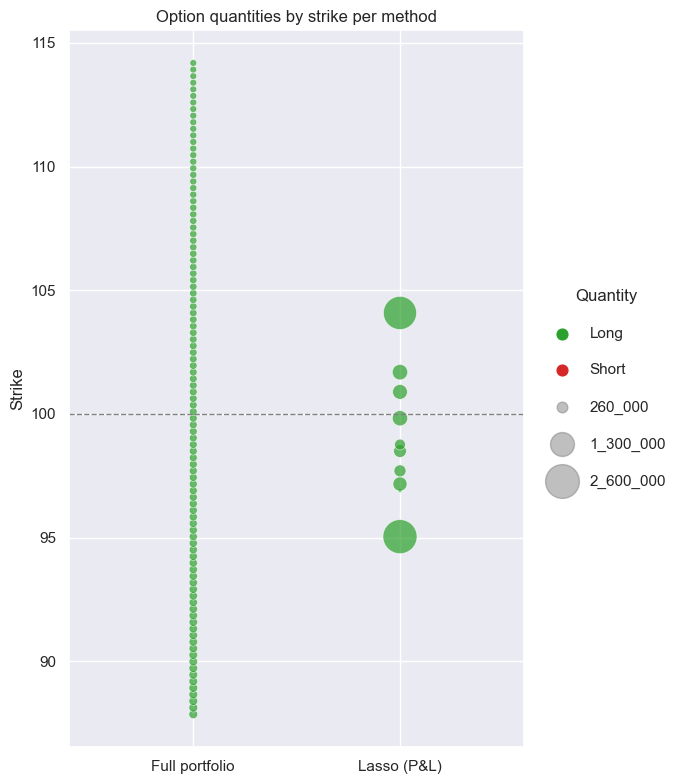

In [42]:
# Strike map of each method: y = strike, x = method, colour = sign of the quantity, dot area proportional to |quantity|
# (same size scale across methods so positions are directly comparable)
def plot_strike_map(method_quantities):
    dots = pd.concat(
        [q[q != 0].rename("quantity").reset_index().assign(method=m) for m, q in method_quantities.items()],
        ignore_index=True,
    )
    max_area = 600
    area_scale = max_area / dots["quantity"].abs().max()
    sign_colors = {True: "tab:green", False: "tab:red"}
    x_pos = {m: i for i, m in enumerate(method_quantities)}

    fig, ax = plt.subplots(figsize=(3 + 2 * len(x_pos), 8))
    ax.scatter(
        dots["method"].map(x_pos), dots["strike"],
        s=dots["quantity"].abs() * area_scale,
        c=(dots["quantity"] > 0).map(sign_colors),
        alpha=0.7, edgecolors="white", linewidths=0.5,
    )
    ax.axhline(S0, color="gray", linestyle="--", linewidth=1)

    # Legend: sign colours and reference sizes
    ref_sizes = [float(f"{q:.2g}") for q in np.array([0.1, 0.5, 1.0]) * dots["quantity"].abs().max()]
    handles = [plt.scatter([], [], s=60, color=sign_colors[True], label="Long"),
               plt.scatter([], [], s=60, color=sign_colors[False], label="Short")]
    handles += [plt.scatter([], [], s=q * area_scale, color="gray", alpha=0.5, label=f"{q:_.0f}") for q in ref_sizes]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), labelspacing=1.5, frameon=False, title="Quantity")

    ax.set_xticks(list(x_pos.values()), list(x_pos.keys()))
    ax.set_xlim(-0.6, len(x_pos) - 0.4)
    ax.set_ylabel("Strike")
    ax.set_title("Option quantities by strike per method")
    plt.tight_layout()
    plt.show()

method_quantities = {
    "Full portfolio": portfolio.set_index("strike")["quantity"],
    "Lasso (P&L)": reduced_portfolio.set_index("strike")["reduced_quantity"],
}
plot_strike_map(method_quantities)

### Terminal payoff lasso

Selected 10 of 100 options (alpha = 188_202_471_632)
Terminal payoff R2 train = 0.9839, test = 0.9845
Hedged P&L R2 test = 0.9285 (P&L lasso: 0.9336)


,strike,option_type,quantity,multiplier,reduced_quantity
put_95.04,95.04,put,150_085,25.31,3_798_498
put_98.76,98.76,put,138_981,1.91,265_466
put_99.03,99.03,put,138_235,3.169,438_126
put_99.29,99.29,put,137_495,0.4328,59_501
put_99.56,99.56,put,136_762,1.141,156_073
put_99.82,99.82,put,136_034,0.976,132_764
call_100.09,100.1,call,135_312,1.172,158_624
call_100.62,100.6,call,133_885,4.925,659_380
call_100.89,100.9,call,133_180,0.4283,57_041
call_104.88,104.9,call,123_240,29.03,3_577_921


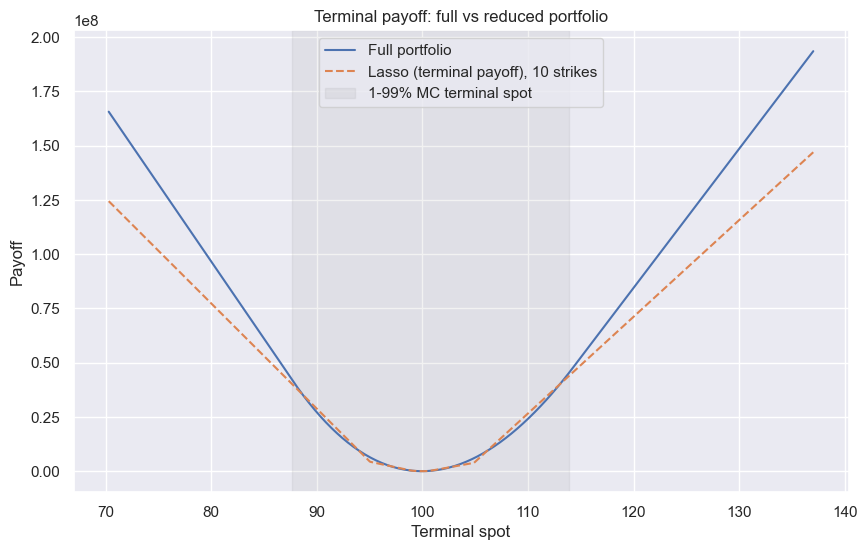

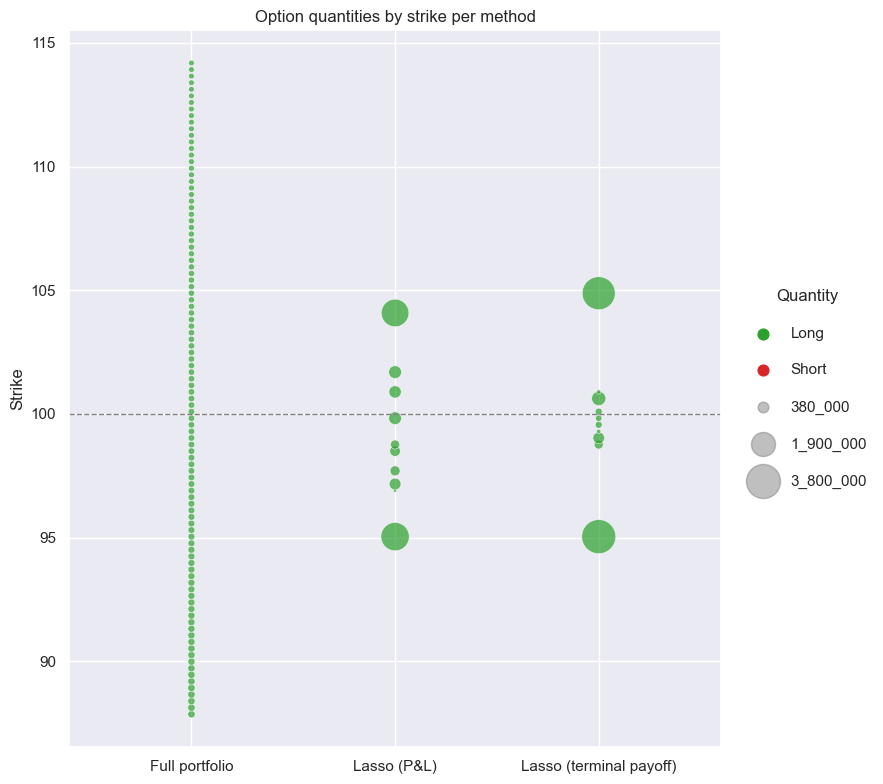

In [43]:
# Features: terminal payoff of each option position; target: terminal payoff of the full portfolio.
# The payoffs are sampled at the Monte Carlo terminal spots, so strikes are weighted by how likely the spot ends there,
# and the same train / test paths as the P&L lasso are used.
terminal_spots = spot_paths[:, -1]
X_payoff = pd.DataFrame(
    np.where(is_call, np.maximum(terminal_spots[:, None] - strikes, 0.0), np.maximum(strikes - terminal_spots[:, None], 0.0)) * quantities,
    index=summary.index, columns=option_names,
)
y_payoff = X_payoff.sum(axis=1)

payoff_candidates, payoff_best = relaxed_lasso(
    X_payoff[train_mask], y_payoff[train_mask], X_payoff[~train_mask], y_payoff[~train_mask], n_selected_options
)
reduced_payoff_portfolio = reduced_positions(payoff_best)
print(f"Selected {payoff_best['n_strikes']} of {n_options} options (alpha = {payoff_best['alpha']:_.0f})")
print(f"Terminal payoff R2 train = {payoff_best['r2_train']:.4f}, test = {payoff_best['r2_test']:.4f}")
print(f"Hedged P&L R2 test = {pnl_r2_test(reduced_payoff_portfolio):.4f} (P&L lasso: {best['r2_test']:.4f})")
display(reduced_payoff_portfolio)

# Terminal payoff of the full vs reduced portfolio on the same spot grid as the Terminal Payoff section
reduced_intrinsic = pd.DataFrame(intrinsic, columns=option_names)[reduced_payoff_portfolio.index].to_numpy()
reduced_terminal_payoff = reduced_intrinsic @ reduced_payoff_portfolio["reduced_quantity"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(terminal_spot, terminal_payoff, label="Full portfolio")
ax.plot(terminal_spot, reduced_terminal_payoff, linestyle="--", label=f"Lasso (terminal payoff), {payoff_best['n_strikes']} strikes")
ax.axvspan(*np.percentile(terminal_spots, [1, 99]), alpha=0.1, color="gray", label="1-99% MC terminal spot")
ax.set_xlabel("Terminal spot")
ax.set_ylabel("Payoff")
ax.set_title("Terminal payoff: full vs reduced portfolio")
ax.legend(loc="upper center")
plt.show()

method_quantities["Lasso (terminal payoff)"] = reduced_payoff_portfolio.set_index("strike")["reduced_quantity"]
plot_strike_map(method_quantities)

### Gamma grid lasso

Selected 10 of 100 options (alpha = 6_258_598_176_233)
Gamma grid R2 train = 0.4758, test = 0.5075
Hedged P&L R2 test = 0.9924 (P&L lasso: 0.9336)


,strike,option_type,quantity,multiplier,reduced_quantity
put_91.31,91.31,put,162_576,17.61,2_862_190
put_94.24,94.24,put,152_638,6.901,1_053_324
put_95.83,95.83,put,147_596,6.732,993_608
put_97.96,97.96,put,141_254,8.489,1_199_037
call_100.09,100.1,call,135_312,2.16,292_320
call_100.36,100.4,call,134_596,6.73,905_868
call_102.75,102.7,call,128_397,9.666,1_241_109
call_105.41,105.4,call,121_999,8.666,1_057_288
call_106.47,106.5,call,119_573,4.616,551_989
call_109.93,109.9,call,112_170,21.31,2_389_849


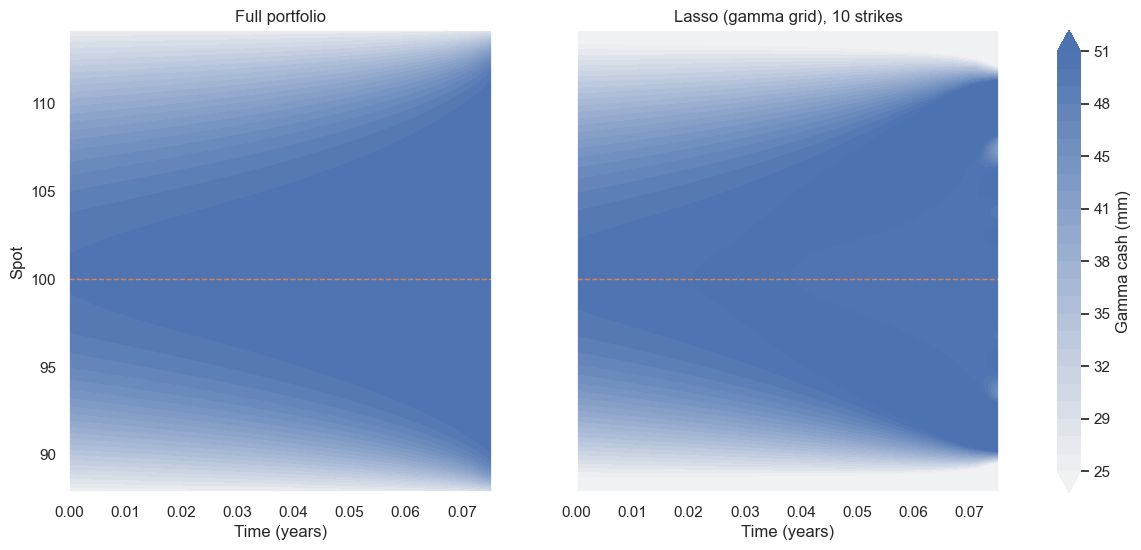

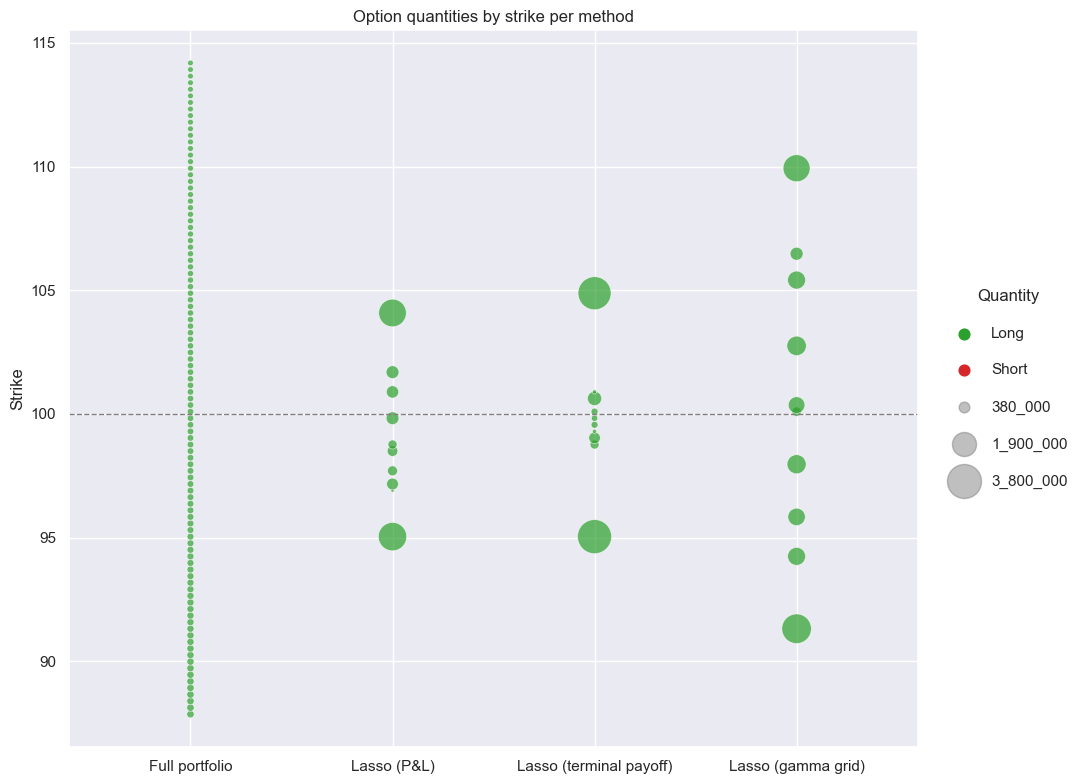

,n_strikes,own_objective_r2_test,hedged_pnl_r2_test
method,,,
Lasso (P&L),10,0.9336,0.9336
Lasso (terminal payoff),10,0.9845,0.9285
Lasso (gamma grid),10,0.5075,0.9924


In [44]:
# Features: gamma cash of each option position on the Gamma Grid (spot x time); target: gamma cash of the full portfolio.
# Every grid point has the same weight; grid points are split into train / test with the same train_fraction.
gamma_cash_by_option = np.empty((spot_grid.size, time_grid.size, n_options))
for j, t in enumerate(time_grid):
    tau = T - t
    F_grid = spot_grid[:, None] * np.exp(r * tau)
    greeks = BSMModel.compute_option_with_forward(F_grid, strikes[None, :], tau, r, sigma, "call", compute_greeks=True)
    gamma_cash_by_option[:, j] = greeks["gamma"] * np.exp(2 * r * tau) * quantities * spot_grid[:, None] ** 2 / 100

X_gamma = pd.DataFrame(gamma_cash_by_option.reshape(-1, n_options), columns=option_names)
y_gamma = X_gamma.sum(axis=1)
grid_train_mask = np.random.default_rng(seed).random(len(X_gamma)) < train_fraction

gamma_candidates, gamma_best = relaxed_lasso(
    X_gamma[grid_train_mask], y_gamma[grid_train_mask], X_gamma[~grid_train_mask], y_gamma[~grid_train_mask], n_selected_options
)
reduced_gamma_portfolio = reduced_positions(gamma_best)
print(f"Selected {gamma_best['n_strikes']} of {n_options} options (alpha = {gamma_best['alpha']:_.0f})")
print(f"Gamma grid R2 train = {gamma_best['r2_train']:.4f}, test = {gamma_best['r2_test']:.4f}")
print(f"Hedged P&L R2 test = {pnl_r2_test(reduced_gamma_portfolio):.4f} (P&L lasso: {best['r2_test']:.4f})")
display(reduced_gamma_portfolio)

# Gamma grid of the full vs reduced portfolio on the full portfolio's colour scale (reduced spikes near expiry saturate)
reduced_gamma_cash = X_gamma[reduced_gamma_portfolio.index].to_numpy() @ reduced_gamma_portfolio["multiplier"].to_numpy()
reduced_gamma_cash_mm = reduced_gamma_cash.reshape(spot_grid.size, time_grid.size) / 1e6
levels = np.linspace(gamma_cash_mm.min(), gamma_cash_mm.max(), 25)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, grid, title in zip(axes, (gamma_cash_mm, reduced_gamma_cash_mm),
                           ("Full portfolio", f"Lasso (gamma grid), {gamma_best['n_strikes']} strikes")):
    filled = ax.contourf(time_grid, spot_grid, grid, levels=levels, cmap=theme_cmap, extend="both")
    ax.axhline(S0, color=sns.color_palette()[1], linewidth=1, linestyle="--")
    ax.grid(False)
    ax.set_xlabel("Time (years)")
    ax.set_title(title)
axes[0].set_ylabel("Spot")
cbar = fig.colorbar(filled, ax=axes, format="%.0f")
cbar.set_label("Gamma cash (mm)")
cbar.outline.set_visible(False)
plt.show()

method_quantities["Lasso (gamma grid)"] = reduced_gamma_portfolio.set_index("strike")["reduced_quantity"]
plot_strike_map(method_quantities)

# Comparison of the three reductions on the common hedged P&L yardstick
comparison = pd.DataFrame(
    {
        "n_strikes": [len(p) for p in (reduced_portfolio, reduced_payoff_portfolio, reduced_gamma_portfolio)],
        "own_objective_r2_test": [best["r2_test"], payoff_best["r2_test"], gamma_best["r2_test"]],
        "hedged_pnl_r2_test": [pnl_r2_test(p) for p in (reduced_portfolio, reduced_payoff_portfolio, reduced_gamma_portfolio)],
    },
    index=pd.Index(["Lasso (P&L)", "Lasso (terminal payoff)", "Lasso (gamma grid)"], name="method"),
)
display(comparison)